In [ ]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(cowplot)
library(monocle)
library(tidyverse)
library(reshape2)
library(ggplot2)
library(ggpubr)
library(GO.db)
library(org.Hs.eg.db)
library(clusterProfiler)
library(enrichplot)
library(ggplot2)
library(ggnewscale)
library(org.Mm.eg.db)
library(dplyr)
library(stringr)
library(ComplexUpset)
options(warn=-1)

In [3]:
#####marophage
mer <- readRDS("./merge_alldata_addmodulescore.RDS")
mer1 <- subset(mer,subset = sample=="save")
mer2 <- subset(mer1,subset = first_type=="Macrophage")

In [4]:
mer1 <- subset(mer,subset = sample=="save")
mer2 <- subset(mer1,subset = first_type=="Macrophage")

Calculating cluster stage1

Calculating cluster stage2

Calculating cluster stage1

Calculating cluster stage3

Calculating cluster stage1

Calculating cluster stage4



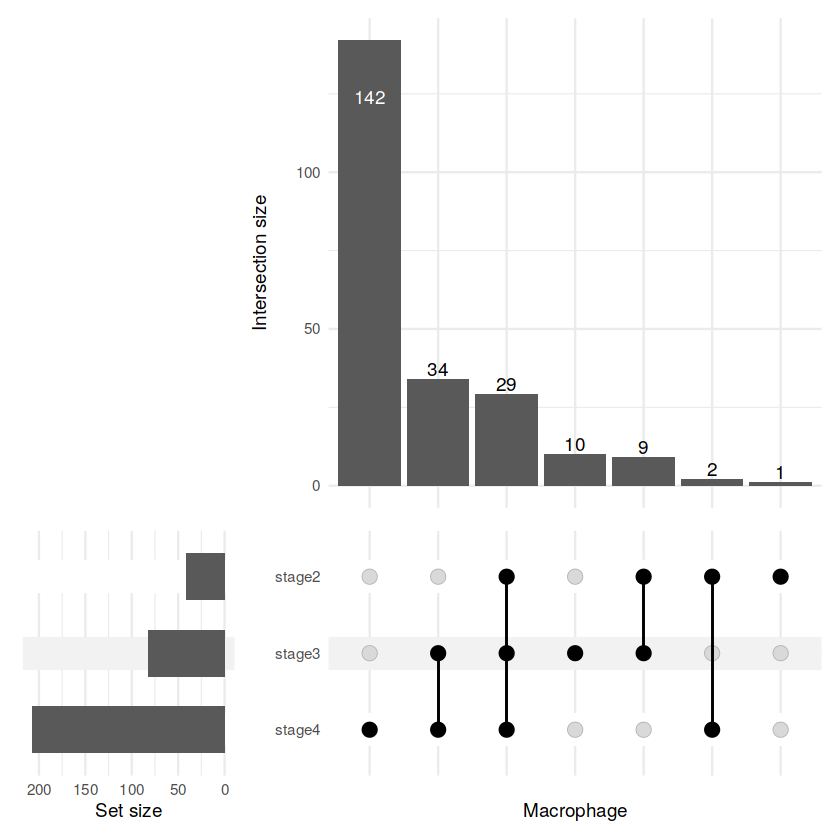

In [5]:
stage <- c('stage2','stage3','stage4')
cell <- c('Fibroblast','SMC','Modulated_SMC','Macrophage','EC')
n=0
for(i in stage){
    n=n+1
    s <- subset(mer2,subset = satge_p_all%in%c("stage1",i))
    c <- subset(s,subset = first_type=="Macrophage")
    Idents(c) <- as.factor(c@meta.data$satge_p_all)
    deg = FindAllMarkers(c,only.pos = FALSE,
                               min.pct = 0.06,
                               logfc.threshold = 0.5)
    deg <- subset(deg,subset=p_val_adj<0.05)
    d <- subset(deg,subset = cluster=="stage1")
    d <- subset(d,select = c("gene"))
    d[,1] <- 1
    colnames(d) <- i
    if(n==1){
        mer <- d
    }
    else{
        mer <- merge(mer,d,all = TRUE,by = 0)
        rownames(mer) <- mer$Row.names
        mer <- mer[,-1]
        
    }
        
}
mer[is.na(mer)] <- 0
week <- c('stage4','stage3','stage2')
upset(mer, week,min_degree = 1,name = "Macrophage",sort_sets=FALSE)
ggsave("MP_upset.pdf",width = 6,height = 5)

In [7]:
saveRDS(mer,"stgae_deg.RDS")

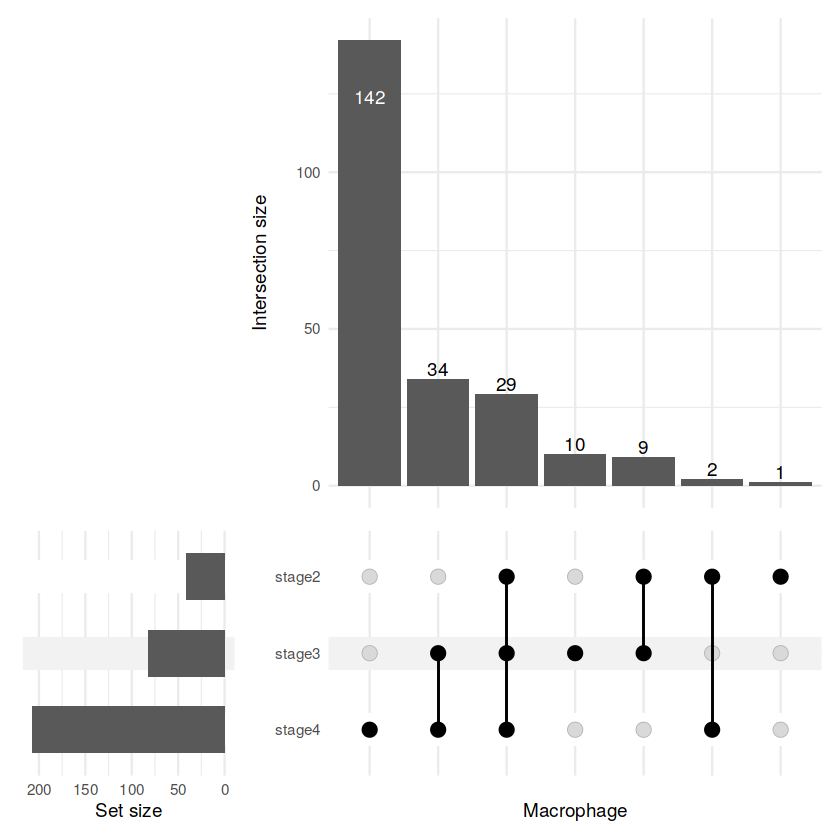

In [6]:
p1 <- upset(mer, week,min_degree = 1,name = "Macrophage",sort_sets=FALSE)
p1

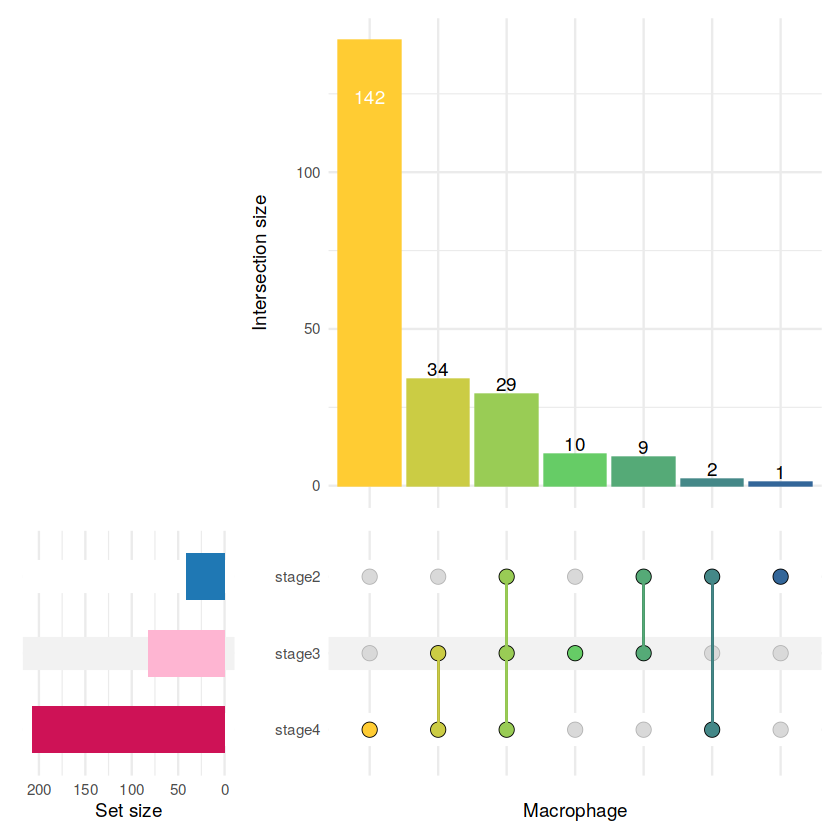

In [7]:
p3 <- upset(mer, week,min_degree = 1,name = "Macrophage",
      sort_sets=FALSE,queries=list(
          upset_query(intersect=c('stage1', 'stage2'),color='#336699',
            fill='#336699',only_components=c('intersections_matrix', 'Intersection size')),
          upset_query(intersect=c('stage1', 'stage2',"stage4"),color='#448888',
            fill='#448888',only_components=c('intersections_matrix', 'Intersection size')),
          upset_query(intersect=c('stage1', 'stage2',"stage3"),color='#55AA77',
            fill='#55AA77',only_components=c('intersections_matrix', 'Intersection size')),
          upset_query(intersect=c('stage1',"stage3"),color='#66CC66',
            fill='#66CC66',only_components=c('intersections_matrix', 'Intersection size')),
          upset_query(intersect=c('stage1',"stage2",'stage3',"stage4"),color='#99CC55',
            fill='#99CC55',only_components=c('intersections_matrix', 'Intersection size')),
          upset_query(intersect=c('stage1','stage3',"stage4"),color='#CBCC44',
            fill='#CBCC44',only_components=c('intersections_matrix', 'Intersection size')),
          upset_query(intersect=c('stage1',"stage4"),color='#FFCC33',
            fill='#FFCC33',only_components=c('intersections_matrix', 'Intersection size')),
            
        upset_query(set='stage2', fill='#1f78b4'),
        upset_query(set='stage3', fill='#FEB5D2'),
        upset_query(set='stage4', fill='#ce1256')))
p3